In [2]:
!pip install --upgrade matplotlib pandas numpy scikit-learn
!pip install --force-reinstall pillow


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
  Using cached pillow-11.3.0-cp39-cp39-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.0 kB)
Using cached pillow-11.3.0-cp39-cp39-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (6.6 MB)
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0


In [3]:
import sys
import os

user_site = os.path.expanduser("~/.local/lib/python3.9/site-packages")
if user_site in sys.path:
    sys.path.remove(user_site)
sys.path.insert(0, user_site)

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt


df = pd.read_csv("train.csv")


df["MSSubClass"] = df["MSSubClass"].astype(str)


X = df.drop(columns=["Id", "SalePrice"]).copy()
y = df["SalePrice"].copy()

print(f"Dataset loaded: Features shape {X.shape} | Target shape {y.shape}")

Dataset loaded: Features shape (1460, 79) | Target shape (1460,)


In [7]:

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print(f"Features partitioned: {len(numeric_cols)} numeric columns, {len(categorical_cols)} total categorical columns.")



Features partitioned: 36 numeric columns, 43 total categorical columns.


In [8]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training split shape: {X_train.shape}")
print(f"Testing split shape:  {X_test.shape}")


Training split shape: (1168, 79)
Testing split shape:  (292, 79)


In [10]:

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])


preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])


model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0))
])

print("Pipeline compiled and ready for training.")



Pipeline compiled and ready for training.


In [11]:
model_pipeline.fit(X_train, y_train)
print("Training sequence complete.")

Training sequence complete.


In [12]:

y_pred = model_pipeline.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"R-squared Score (Accuracy Variance): {r2 * 100:.2f}%")


--- Final Evaluation Results ---
Mean Absolute Error (MAE): $19,108.83
R-squared Score (Accuracy Variance): 88.48%


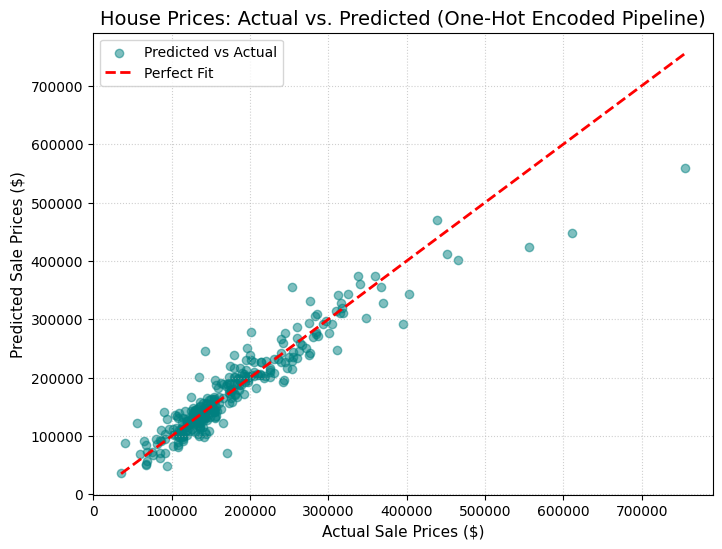

In [13]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color="teal", label="Predicted vs Actual")


perfect_line = [min(y_test), max(y_test)]
plt.plot(perfect_line, perfect_line, color="red", linestyle="--", linewidth=2, label="Perfect Fit")

plt.title("House Prices: Actual vs. Predicted (One-Hot Encoded Pipeline)", fontsize=14)
plt.xlabel("Actual Sale Prices ($)", fontsize=11)
plt.ylabel("Predicted Sale Prices ($)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.show()



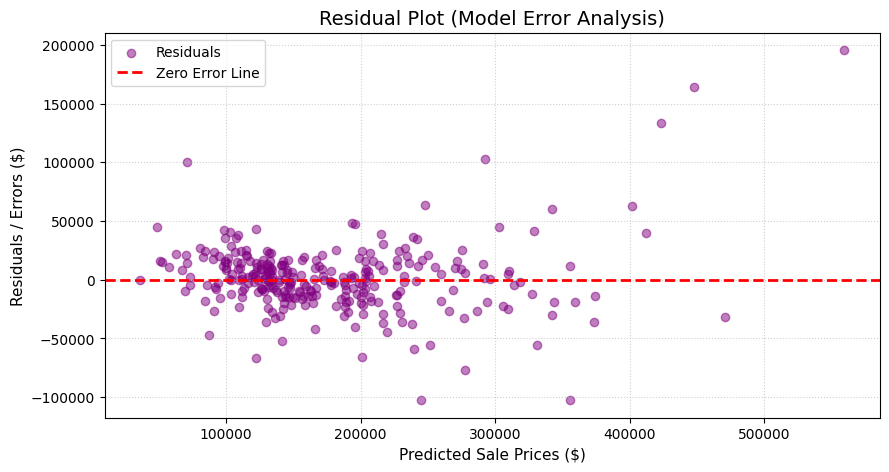

In [14]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color="purple", label="Residuals")
plt.axhline(y=0, color="red", linestyle="--", linewidth=2, label="Zero Error Line")

plt.title("Residual Plot (Model Error Analysis)", fontsize=14)
plt.xlabel("Predicted Sale Prices ($)", fontsize=11)
plt.ylabel("Residuals / Errors ($)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.show()

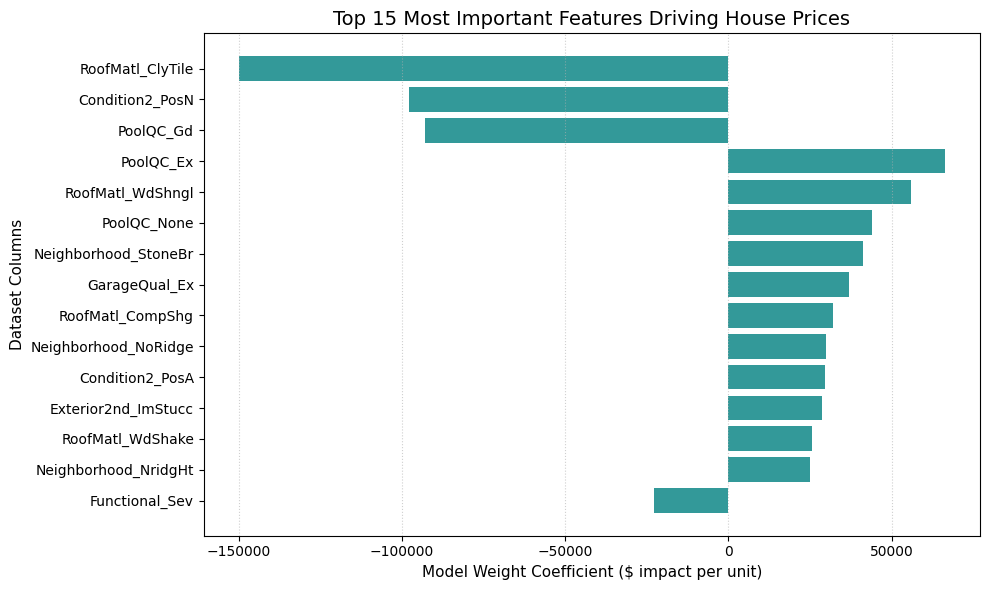

In [15]:
ohe_feature_names = model_pipeline.named_steps['preprocessor']\
                                   .named_transformers_['cat']\
                                   .named_steps['onehot']\
                                   .get_feature_names_out(categorical_cols).tolist()

all_features = numeric_cols + ohe_feature_names
coefficients = model_pipeline.named_steps['regressor'].coef_


importance_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': coefficients
})
importance_df['Abs_Coefficient'] = importance_df['Coefficient'].abs()
top_features = importance_df.sort_values(by='Abs_Coefficient', ascending=False).head(15)


plt.figure(figsize=(10, 6))
colors = ['emerald' if c > 0 else 'crimson' for c in top_features['Coefficient']]
bars = plt.barh(top_features['Feature'], top_features['Coefficient'], color='teal', alpha=0.8)

plt.title("Top 15 Most Important Features Driving House Prices", fontsize=14)
plt.xlabel("Model Weight Coefficient ($ impact per unit)", fontsize=11)
plt.ylabel("Dataset Columns", fontsize=11)
plt.gca().invert_yaxis() 
plt.grid(True, axis='x', linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()